# Sewellia lineolata time-resolved CT — data preview

Dataset: `SL2022_3_SC_10kHz_550Hz_0deg_1p8Vpp_4D_01.h5`

This is a **periodic time-resolved CT** dataset (fish inner-ear / sound-stimulation experiment),
associated with the paper *"Analytical Reconstruction of Periodically Deformed Objects in
Time-resolved CT"* ([arXiv:2506.03792](https://arxiv.org/abs/2506.03792), code:
[14N16O/PeriodRecon](https://github.com/14N16O/PeriodRecon), formerly `PeriodRecon/PeriodRecon`).

Unlike our other time-resolved datasets (`.mov` continuous acquisitions + separate darks/flats),
this file ships an **already flat/dark-corrected sinogram** directly (see `demo.ipynb` in the
PeriodRecon repo — they load `sinogram`, `phase`, `theta` straight into `tomopy.recon`). There are
no raw darks/flats groups in this file — normalization has already been applied upstream.

For every projection `i` we have two parameters that together fully determine the acquisition:
- `theta[i]`: the (slow) rotation angle of the sample, in degrees.
- `phase[i]`: the (fast) periodic-motion phase, in radians (`0` .. `2*pi`), driven by the
  `550 Hz` acoustic stimulation encoded in the filename.

So a single continuous 10 kHz acquisition simultaneously sweeps a *slow* rotation (for
tomography) and samples a *fast* periodic oscillation (for the dynamics) — theta and phase are
essentially independent clocks running at very different rates, which is what lets a
gating/harmonic reconstruction separate "static structure" (theta) from "dynamic deformation"
(phase).

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3d projection)

DATA_PATH = "/myhome/data/sdate/shared/time_resolved/sewellia_lineolata/SL2022_3_SC_10kHz_550Hz_0deg_1p8Vpp_4D_01.h5"

with h5py.File(DATA_PATH, "r") as f:
    print("Groups/datasets in file:")
    f.visititems(lambda name, obj: print(" ", name, obj.shape if hasattr(obj, "shape") else "", obj.dtype if hasattr(obj, "dtype") else ""))
    sinogram = f["sinogram"][:]
    theta = f["theta"][:]
    phase = f["phase"][:]

print()
print(f"sinogram shape (n_proj, n_rows, n_pix): {sinogram.shape}, dtype={sinogram.dtype}")
print(f"theta shape: {theta.shape}, dtype={theta.dtype}")
print(f"phase shape: {phase.shape}, dtype={phase.dtype}")

Groups/datasets in file:
  phase (20000,) float32
  sinogram (20000, 6, 556) float32
  theta (20000,) float32



sinogram shape (n_proj, n_rows, n_pix): (20000, 6, 556), dtype=float32
theta shape: (20000,), dtype=float32
phase shape: (20000,), dtype=float32


## 1. Basic statistics

Number of projections, acquisition rate/duration, angular coverage, motion-phase coverage, and
the dynamic range of the (already-corrected) sinogram values.

In [2]:
FRAME_RATE_HZ = 10_000.0   # from filename: 10kHz
NOMINAL_MOTION_HZ = 550.0  # from filename: 550Hz

n_proj, n_rows, n_pix = sinogram.shape
duration_s = n_proj / FRAME_RATE_HZ

# theta: slow rotation
theta_span = theta.max() - theta.min()
theta_step = np.diff(theta)
n_theta_reversals = int(np.sum(theta_step < 0))  # sanity check: should stay monotonic

# phase: fast periodic motion. Count 2*pi wrap-arounds to get the *measured* number of
# motion cycles actually captured in the acquisition, and compare to the nominal frequency.
dphase = np.diff(phase)
n_wraps = int(np.sum(dphase < -np.pi))  # a wrap looks like a big negative jump
measured_motion_hz = n_wraps / duration_s

print(f"Number of projections:        {n_proj}")
print(f"Detector rows x pixels:       {n_rows} x {n_pix}  (thin ROI sinogram, not a full 2D detector frame)")
print(f"Frame rate (assumed):         {FRAME_RATE_HZ:.0f} Hz")
print(f"Acquisition duration:         {duration_s:.3f} s")
print()
print(f"theta range:                  [{theta.min():.3f}, {theta.max():.3f}] deg  (span={theta_span:.3f} deg)")
print(f"theta monotonic increasing:   {n_theta_reversals == 0}")
print(f"theta step (deg/frame):       min={theta_step.min():.5f} max={theta_step.max():.5f} mean={theta_step.mean():.5f}")
print(f"  -> implied full-360 rotation period: {360.0/ (theta_step.mean()*FRAME_RATE_HZ):.2f} s"
      f" (this acquisition covers ~{theta_span:.1f} deg, i.e. a single half-turn / parallel-beam sweep)")
print()
print(f"phase range:                  [{phase.min():.4f}, {phase.max():.4f}] rad")
print(f"Number of 2*pi phase wraps:   {n_wraps}")
print(f"Measured motion frequency:    {measured_motion_hz:.2f} Hz  (nominal from filename: {NOMINAL_MOTION_HZ:.0f} Hz)")
print(f"  -> {n_wraps} motion cycles sampled over the full theta sweep")
print()
print("Sinogram value statistics (already flat/dark-corrected; looks like transmission I/I0, not yet -log'd):")
print(f"  min={sinogram.min():.4f}  max={sinogram.max():.4f}  mean={sinogram.mean():.4f}  std={sinogram.std():.4f}")
for p in (0.1, 1, 50, 99, 99.9):
    print(f"  p{p:>5}: {np.percentile(sinogram, p):.4f}")
print()
print("Per-row mean (6 detector rows) — checks for row-to-row gain differences:")
print("  ", np.round(sinogram.mean(axis=(0, 2)), 4))
print()
print(f"File size on disk: {__import__('os').path.getsize(DATA_PATH) / 1e6:.1f} MB")

Number of projections:        20000
Detector rows x pixels:       6 x 556  (thin ROI sinogram, not a full 2D detector frame)
Frame rate (assumed):         10000 Hz
Acquisition duration:         2.000 s

theta range:                  [0.254, 180.246] deg  (span=179.992 deg)
theta monotonic increasing:   True
theta step (deg/frame):       min=0.00887 max=0.00912 mean=0.00900
  -> implied full-360 rotation period: 4.00 s (this acquisition covers ~180.0 deg, i.e. a single half-turn / parallel-beam sweep)

phase range:                  [0.0000, 6.2828] rad
Number of 2*pi phase wraps:   1100
Measured motion frequency:    550.00 Hz  (nominal from filename: 550 Hz)
  -> 1100 motion cycles sampled over the full theta sweep

Sinogram value statistics (already flat/dark-corrected; looks like transmission I/I0, not yet -log'd):


  min=-1.1818  max=2.0705  mean=0.9654  std=0.1400


  p  0.1: 0.5688


  p    1: 0.6751


  p   50: 0.9519


  p   99: 1.3545


  p 99.9: 1.5179

Per-row mean (6 detector rows) — checks for row-to-row gain differences:
   [0.976  0.9755 0.9534 0.9631 0.9739 0.9505]

File size on disk: 267.0 MB


## 2. `(theta, phi)` coverage on a cylinder

`theta` is the rotation angle (the cylinder's azimuthal coordinate) and `phase` is the
periodic-motion phase (the cylinder's height). Full coverage of this cylinder is exactly what a
combined tomography + phase-resolved reconstruction needs — gaps here would show up as gaps in
the reconstructed dynamics at some rotation angles.

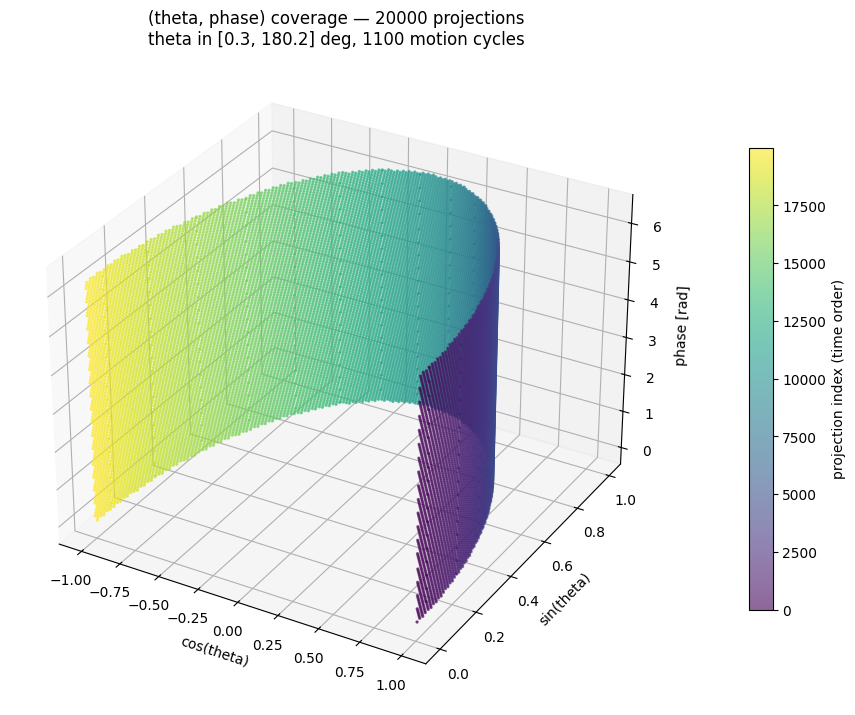

In [3]:
theta_rad = np.deg2rad(theta)
R = 1.0
x = R * np.cos(theta_rad)
y = R * np.sin(theta_rad)
z = phase

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(x, y, z, c=np.arange(n_proj), cmap="viridis", s=2, alpha=0.6)
ax.set_xlabel("cos(theta)")
ax.set_ylabel("sin(theta)")
ax.set_zlabel("phase [rad]")
ax.set_title(f"(theta, phase) coverage — {n_proj} projections\ntheta in [{theta.min():.1f}, {theta.max():.1f}] deg, "
             f"{n_wraps} motion cycles")
cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label("projection index (time order)")
plt.tight_layout()
plt.savefig("sewellia_theta_phase_cylinder.png", dpi=150)
plt.show()

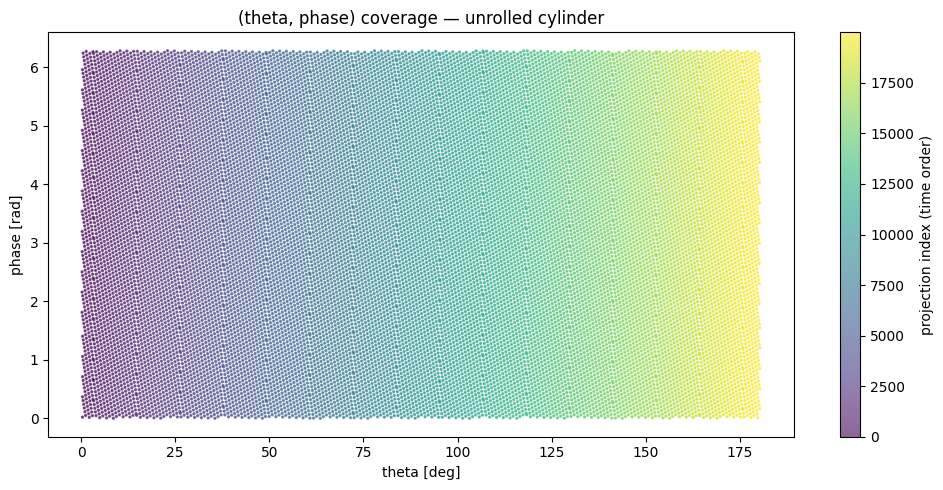

In [4]:
# 2D unrolled view (theta vs phase) is often easier to read for coverage/gaps than the 3D cylinder
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(theta, phase, c=np.arange(n_proj), cmap="viridis", s=2, alpha=0.6)
ax.set_xlabel("theta [deg]")
ax.set_ylabel("phase [rad]")
ax.set_title("(theta, phase) coverage — unrolled cylinder")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("projection index (time order)")
plt.tight_layout()
plt.savefig("sewellia_theta_phase_unrolled.png", dpi=150)
plt.show()

## 3. A few projections, and how noisy they are

Each "projection" `sinogram[i]` is a thin `(6, 556)` slab (only 6 detector rows were kept in this
file — likely a small ROI slab rather than a full detector frame). We look at:
- a handful of full projections across the acquisition,
- single-row sinograms (projection index vs. detector pixel) to see the noise texture directly,
- a simple high-pass noise estimate (since the underlying attenuation profile is spatially
  smooth, the pixel-to-pixel second difference is a reasonable proxy for the noise floor).

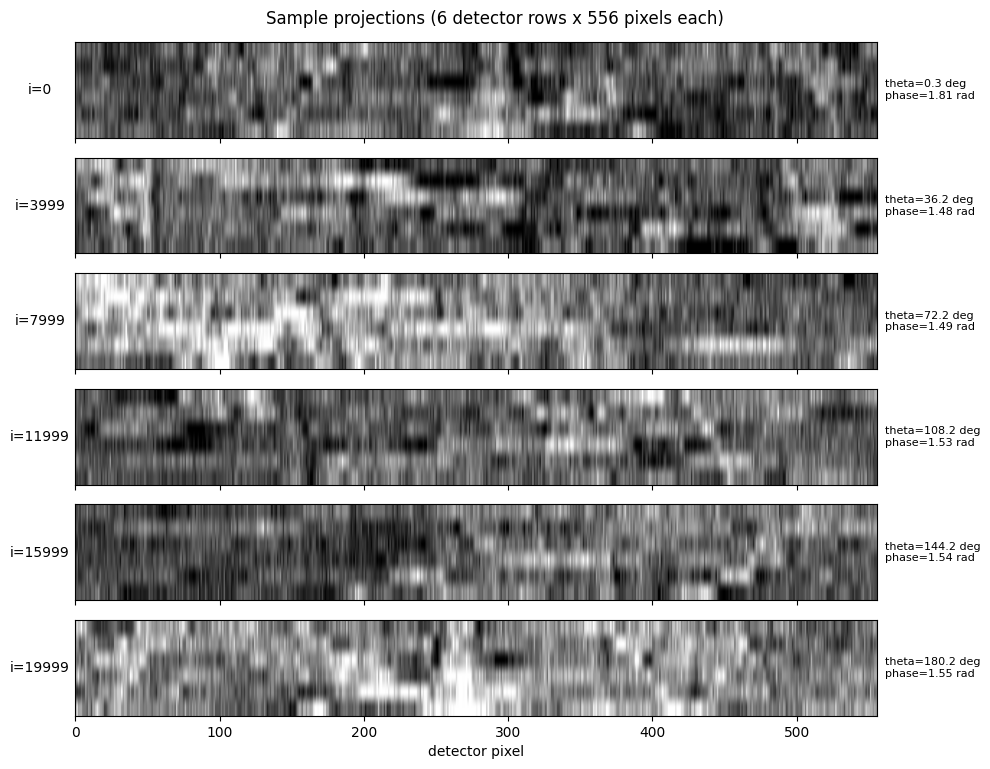

In [5]:
sample_idx = np.linspace(0, n_proj - 1, 6, dtype=int)

fig, axes = plt.subplots(len(sample_idx), 1, figsize=(10, 1.3 * len(sample_idx)), sharex=True)
vmin, vmax = np.percentile(sinogram, [1, 99])
for ax, i in zip(axes, sample_idx):
    im = ax.imshow(sinogram[i], aspect="auto", cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_ylabel(f"i={i}", rotation=0, labelpad=25, va="center")
    ax.set_yticks([])
    ax.text(1.01, 0.5, f"theta={theta[i]:.1f} deg\nphase={phase[i]:.2f} rad",
            transform=ax.transAxes, va="center", fontsize=8)
axes[-1].set_xlabel("detector pixel")
fig.suptitle("Sample projections (6 detector rows x 556 pixels each)")
plt.tight_layout()
plt.savefig("sewellia_sample_projections.png", dpi=150)
plt.show()

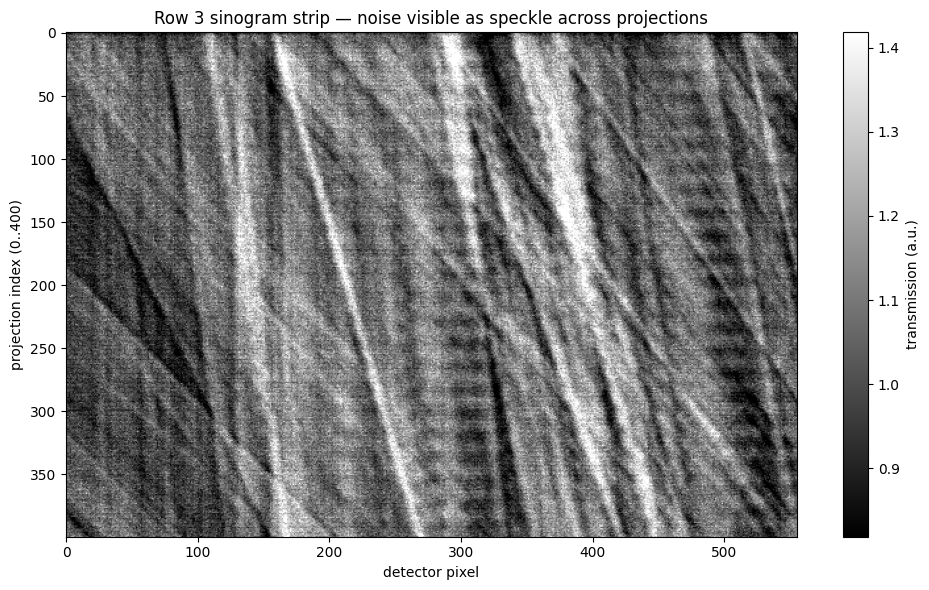

In [6]:
# A single row, over a short run of consecutive projections, as an image:
# rows = projection index (time), columns = detector pixel. This is the clearest way to see
# per-shot noise texture (each horizontal line is one acquisition).
row = 3
i0, i1 = 0, 400  # ~1 motion cycle is ~18 projections, so this spans ~22 cycles
strip = sinogram[i0:i1, row, :]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(strip, aspect="auto", cmap="gray",
               vmin=np.percentile(strip, 1), vmax=np.percentile(strip, 99))
ax.set_xlabel("detector pixel")
ax.set_ylabel(f"projection index ({i0}..{i1})")
ax.set_title(f"Row {row} sinogram strip — noise visible as speckle across projections")
fig.colorbar(im, ax=ax, label="transmission (a.u.)")
plt.tight_layout()
plt.savefig("sewellia_row_sinogram_strip.png", dpi=150)
plt.show()

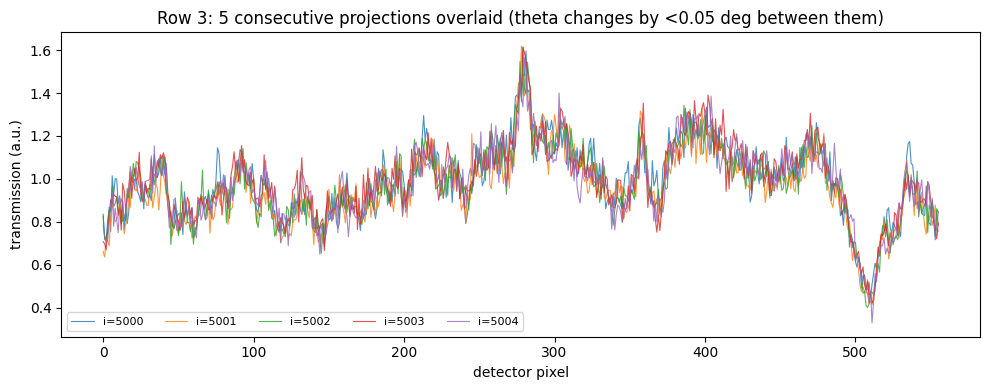

Estimated per-pixel noise std (high-pass proxy): 0.05517
  as a fraction of the mean signal level (0.9654): 5.71%
  per-row breakdown:
    row 0: noise std ~ 0.05576


    row 1: noise std ~ 0.05568
    row 2: noise std ~ 0.05466


    row 3: noise std ~ 0.05521
    row 4: noise std ~ 0.05545


    row 5: noise std ~ 0.05424


In [7]:
# Line profiles: overlay a few consecutive projections (same theta/phase neighborhood,
# ~0.009 deg apart in theta) to eyeball noise vs. the smooth underlying attenuation profile.
i0 = 5000
fig, ax = plt.subplots(figsize=(10, 4))
for di in range(5):
    ax.plot(sinogram[i0 + di, row, :], lw=0.8, alpha=0.8, label=f"i={i0+di}")
ax.set_xlabel("detector pixel")
ax.set_ylabel("transmission (a.u.)")
ax.set_title(f"Row {row}: 5 consecutive projections overlaid (theta changes by <0.05 deg between them)")
ax.legend(fontsize=8, ncol=5)
plt.tight_layout()
plt.savefig("sewellia_line_profiles.png", dpi=150)
plt.show()

# Quantitative noise proxy: std of the second finite difference along the detector-pixel axis,
# divided by sqrt(6) (variance of a discrete 2nd-derivative kernel [1,-2,1] is 6*sigma^2 for iid noise).
# This estimates the per-pixel noise std assuming the true signal is smooth on this scale.
d2 = sinogram[:, :, :-2] - 2 * sinogram[:, :, 1:-1] + sinogram[:, :, 2:]
noise_std_est = d2.std() / np.sqrt(6)
print(f"Estimated per-pixel noise std (high-pass proxy): {noise_std_est:.5f}")
print(f"  as a fraction of the mean signal level ({sinogram.mean():.4f}): {100*noise_std_est/sinogram.mean():.2f}%")
print(f"  per-row breakdown:")
for r in range(n_rows):
    d2_r = sinogram[:, r, :-2] - 2 * sinogram[:, r, 1:-1] + sinogram[:, r, 2:]
    print(f"    row {r}: noise std ~ {d2_r.std()/np.sqrt(6):.5f}")

## 5. The REAL full acquisition has landed: raw counts + darks + flats + theta

The file above (`SL2022_3_SC_10kHz_550Hz_0deg_1p8Vpp_4D_01.h5`) turned out to be a small,
**already flat/dark-corrected** excerpt (6 detector rows only, no raw counts). The full
acquisition has now landed at:

```
/myhome/data/sdate/shared/time_resolved/sewellia_lineolata/SL2022_3_SC_10kHz_550Hz_0deg_1p8Vpp_4D_01/
```

This is a genuine **PSI/TOMCAT beamline** acquisition folder (GigaFRoST camera), not a `.mov`
stream like our other datasets, but a standard **DataExchange-style HDF5** — same *kind* of
information as `.mov` (raw counts + darks + flats + rotation angle), just a different
container format. Alongside the (13 GB) `.h5` file there's a `_sound_phase.txt` sidecar —
**this is where phi lives**: it's the answer to "do we have (theta, phi) pairs explicitly" —
**yes, both are explicit**, just in two different places:

- **theta**: `exchange/theta` inside the h5 (one value per projection).
- **phi**: the sidecar `..._sound_phase.txt` (one value per line, same order/count as the
  projections) — there is no `phi`/`phase` dataset inside the h5 itself.

Confirmed by direct comparison: `exchange/theta` and `sound_phase.txt` match the small
preview file's `theta`/`phase` arrays to float32 rounding precision — this really is the same
acquisition, the preview was just a pre-corrected, cropped-to-6-rows excerpt of it.

In [8]:
import h5py
import numpy as np

FULL_DIR = "/myhome/data/sdate/shared/time_resolved/sewellia_lineolata/SL2022_3_SC_10kHz_550Hz_0deg_1p8Vpp_4D_01"
FULL_H5 = f"{FULL_DIR}/SL2022_3_SC_10kHz_550Hz_0deg_1p8Vpp_4D_01.h5"
PHASE_TXT = f"{FULL_DIR}/SL2022_3_SC_10kHz_550Hz_0deg_1p8Vpp_4D_01_sound_phase.txt"

f_full = h5py.File(FULL_H5, "r")  # kept open -- 13GB file, we only ever slice it, never f_full['exchange/data'][:]
print("Structure:")
f_full.visititems(lambda name, obj: print(" ", name, getattr(obj, "shape", "(group)"), getattr(obj, "dtype", "")))

theta_full = f_full["exchange/theta"][:]
phase_full = np.loadtxt(PHASE_TXT)
print()
print(f"theta_full: {theta_full.shape}, range [{theta_full.min():.3f},{theta_full.max():.3f}] deg")
print(f"phase_full (sound_phase.txt): {phase_full.shape}, range [{phase_full.min():.3f},{phase_full.max():.3f}] rad")
print(f"max|theta_full - theta(preview)| = {np.max(np.abs(theta_full - theta)):.2e} deg")
print(f"max|phase_full - phase(preview)| = {np.max(np.abs(phase_full - phase)):.2e} rad")
print()
print(f"Frame shape (full, uncropped): {f_full['exchange/data'].shape[1:]}  "
      f"(vs. the preview's cropped 6x556 slab)")
print(f"n_proj={f_full['exchange/data'].shape[0]}  n_dark={f_full['exchange/data_dark'].shape[0]}  "
      f"n_white={f_full['exchange/data_white'].shape[0]}")
print(f"raw dtype: {f_full['exchange/data'].dtype}")

Structure:
  exchange (group) 
  exchange/data (20000, 580, 576) uint16
  exchange/data_dark (50, 580, 576) uint16
  exchange/data_white (100, 580, 576) uint16
  exchange/theta (20000,) float64
  exchange/theta_dark (50,) float64
  exchange/theta_dark_raw (50,) float64
  exchange/theta_raw (20000,) float64
  exchange/theta_white (100,) float64
  exchange/theta_white_raw (100,) float64
  implements () object
  measurement (group) 
  measurement/instrument (group) 
  measurement/instrument/acquisition (group) 
  measurement/instrument/acquisition/data (20000,) [('image_is_complete', '?'), ('scan_index', '<i8'), ('image_exposure_time', '<i8'), ('enable_signal', '<i8'), ('image_sync_time', '<i8'), ('trigger_signal', '<i8'), ('scan_datetime', '<i8'), ('time_stamp', '<i8'), ('image_number', '<i8')]
  measurement/instrument/acquisition/data_dark (50,) [('image_is_complete', '?'), ('scan_index', '<i8'), ('image_exposure_time', '<i8'), ('enable_signal', '<i8'), ('image_sync_time', '<i8'), ('tri

### Darks and flats

Real per-pixel calibration frames are now available (50 darks, 100 flats/whites) — the
Poisson-based denoising losses developed for wunderkerze2 (`nb_nll`/`nb_nll_gaussian`) need
exactly this (a real dark-frame variance map for the read-noise floor), unlike the preview
file which had none.

dark mean: overall=51.602  median=51.760
dark var:  overall=64.232  median=64.670  (std~8.015 counts)
flat/white mean: overall=268.966  median=269.530


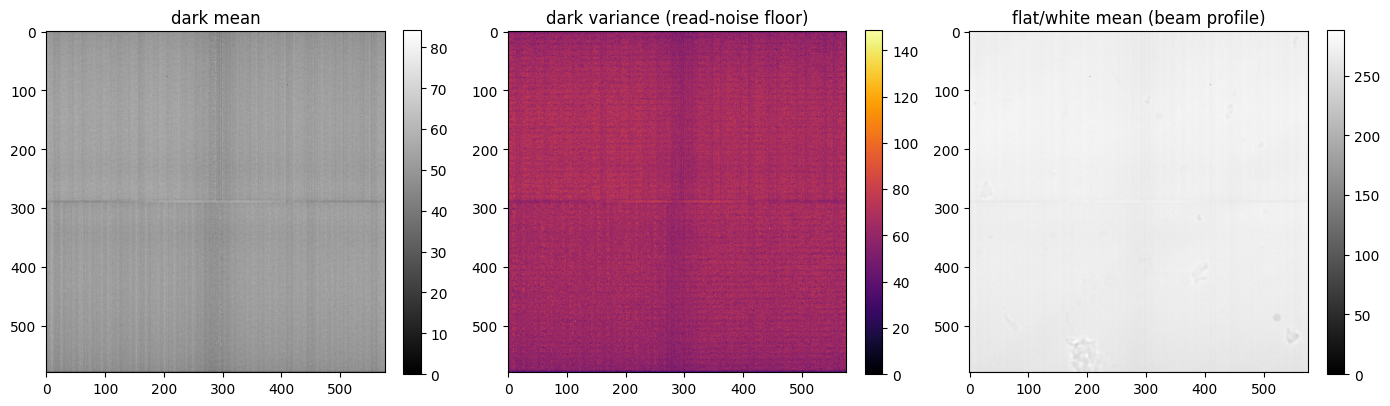

In [9]:
dark_stack = f_full["exchange/data_dark"][:].astype(np.float32)
white_stack = f_full["exchange/data_white"][:].astype(np.float32)

dark_mean = dark_stack.mean(axis=0)
dark_var = dark_stack.var(axis=0)
white_mean = white_stack.mean(axis=0)

print(f"dark mean: overall={dark_mean.mean():.3f}  median={np.median(dark_mean):.3f}")
print(f"dark var:  overall={dark_var.mean():.3f}  median={np.median(dark_var):.3f}  "
      f"(std~{np.sqrt(dark_var.mean()):.3f} counts)")
print(f"flat/white mean: overall={white_mean.mean():.3f}  median={np.median(white_mean):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
im0 = axes[0].imshow(dark_mean, cmap="gray")
axes[0].set_title("dark mean")
fig.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(dark_var, cmap="inferno")
axes[1].set_title("dark variance (read-noise floor)")
fig.colorbar(im1, ax=axes[1], fraction=0.046)
im2 = axes[2].imshow(white_mean, cmap="gray")
axes[2].set_title("flat/white mean (beam profile)")
fig.colorbar(im2, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.savefig("sewellia_full_darks_flats.png", dpi=150)
plt.show()

### A few real, FULL (580x576) projections

Unlike the preview's thin 6-row slab, these are genuine 2D projection images. Shown raw
(noisy counts) and flat/dark-corrected (transmission) side by side.

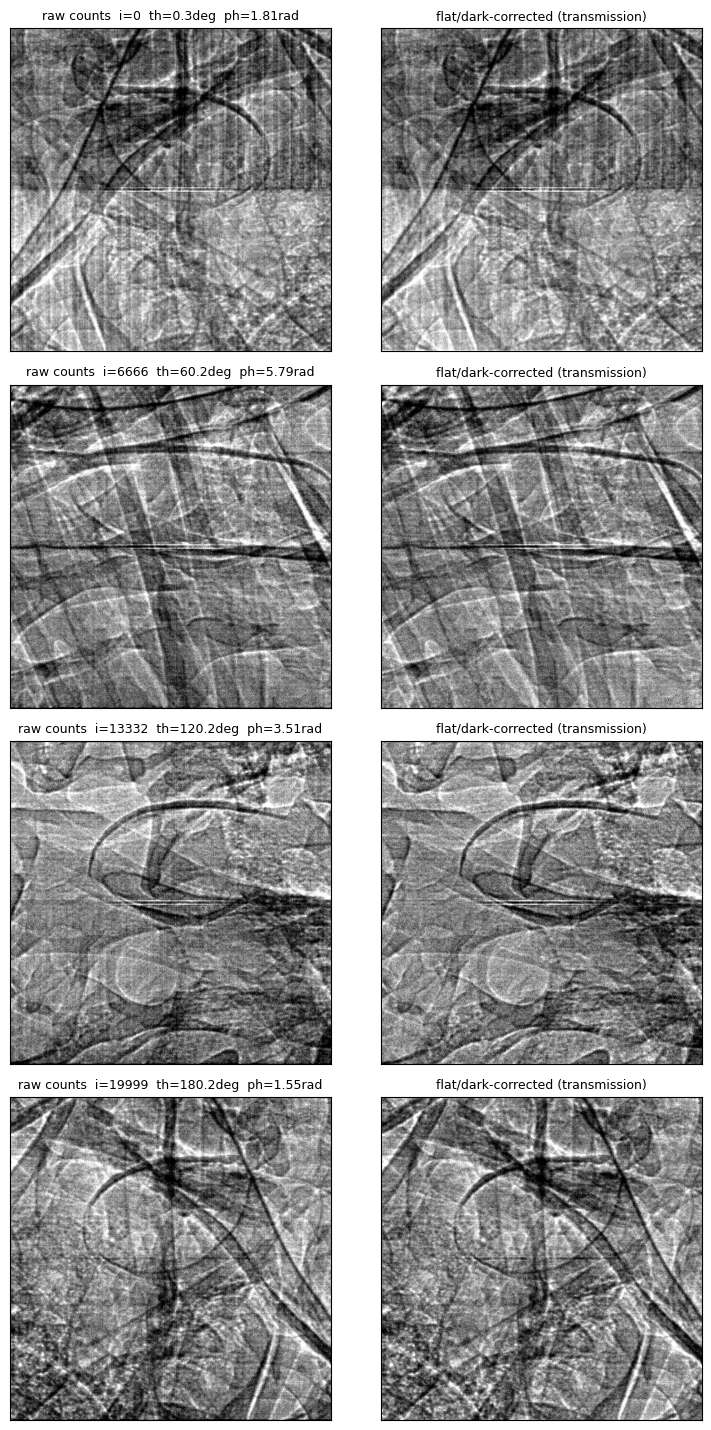

In [10]:
sample_full_idx = np.linspace(0, theta_full.shape[0] - 1, 4, dtype=int)

fig, axes = plt.subplots(len(sample_full_idx), 2, figsize=(8, 3.6 * len(sample_full_idx)))
span = np.clip(white_mean - dark_mean, 1e-3, None)
for row, i in enumerate(sample_full_idx):
    raw = f_full["exchange/data"][int(i)].astype(np.float32)  # single-frame slice, not a full-array load
    transmission = (raw - dark_mean) / span

    ax = axes[row, 0]
    ax.imshow(raw, cmap="gray", vmin=np.percentile(raw, 1), vmax=np.percentile(raw, 99))
    ax.set_title(f"raw counts  i={i}  th={theta_full[i]:.1f}deg  ph={phase_full[i]:.2f}rad", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

    ax = axes[row, 1]
    ax.imshow(transmission, cmap="gray", vmin=np.percentile(transmission, 1), vmax=np.percentile(transmission, 99))
    ax.set_title("flat/dark-corrected (transmission)", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("sewellia_full_sample_projections.png", dpi=150)
plt.show()

### Basic statistics (full acquisition)

Raw counts are read via a strided SUBSAMPLE of the 13 GB `exchange/data` array (never loaded
whole) -- cheap, and representative for dynamic-range/noise-level purposes.

In [11]:
stride = 200
sub_idx = np.arange(0, theta_full.shape[0], stride)
raw_sub = f_full["exchange/data"][sub_idx].astype(np.float32)  # (100, 580, 576)

print(f"Full acquisition: {theta_full.shape[0]} projections, {dark_stack.shape[0]} darks, "
      f"{white_stack.shape[0]} flats, frame shape {f_full['exchange/data'].shape[1:]}")
print(f"Raw counts (subsample every {stride}th frame): "
      f"min={raw_sub.min():.0f} max={raw_sub.max():.0f} mean={raw_sub.mean():.2f} std={raw_sub.std():.2f}")
for p in (0.1, 50, 99.9):
    print(f"  p{p:>5}: {np.percentile(raw_sub, p):.1f}")
print(f"Flat mean level: {white_mean.mean():.1f}  (SNR proxy sqrt(flat_mean)={np.sqrt(white_mean.mean()):.1f} counts, "
      f"consistent with a real low-dose Poisson regime -- exposure was only {0.095} ms/frame at 10kHz)")

file_size_gb = f_full["exchange/data"].size * f_full["exchange/data"].dtype.itemsize / 1e9
print(f"exchange/data raw size: {file_size_gb:.2f} GB")

Full acquisition: 20000 projections, 50 darks, 100 flats, frame shape (580, 576)
Raw counts (subsample every 200th frame): min=0 max=946 mean=135.05 std=11.42


  p  0.1: 80.0


  p   50: 135.0


  p 99.9: 173.0
Flat mean level: 269.0  (SNR proxy sqrt(flat_mean)=16.4 counts, consistent with a real low-dose Poisson regime -- exposure was only 0.095 ms/frame at 10kHz)
exchange/data raw size: 13.36 GB


### What this changes for the phi-context / N2V plan

- **theta, phi are both explicit** (h5 `exchange/theta` + sidecar `sound_phase.txt`), confirmed
  identical to what we already validated the phi-gated joint-FBP mechanism against.
- **Real raw counts + real darks/flats are now available** -- the `phi_context.py` module's
  `dark`/`flat`-aware path (built for exactly this, with the trivial `dark=0,flat=1` case used
  only as a stand-in for the precorrected preview file) can now be used with the REAL
  calibration maps computed above, instead of the identity placeholder.
- **A genuine Poisson noise regime** (low counts, ~121 mean vs. a flat level of ~230) means the
  project's existing Poisson-based losses (`nb_nll`, `nb_nll_gaussian`, with the dark-variance
  read-noise floor computed above) can be reused as-is for training on this dataset, superseding
  the plain Gaussian/L2 loss used for the precorrected-preview-only prototype.
- Frames are much bigger now (580x576 vs. 6x556) -- a real 2D U-Net input, no longer needing the
  `PaddedUNet` hack built for the 6-pixel-tall preview slab (580 and 576 are still not multiples
  of 32, so *some* padding/cropping is still needed, just a much smaller relative amount).

## 4. Notes / caveats

- This file only contains `sinogram` / `theta` / `phase` — **no separate darks/flats** like our
  `.mov`-based datasets. The sinogram values (centered ~1, no negatives) look like flat/dark
  corrected transmission (`I/I0`) that has **not** yet been `-log`'d into line integrals; the
  PeriodRecon `demo.ipynb` feeds this array straight into `tomopy.recon(..., algorithm="gridrec")`
  without an explicit `-log` step, so either tomopy's gridrec is being handed transmission data
  directly, or a `-log` happens implicitly elsewhere in their pipeline — worth double-checking
  against the paper if we build our own reconstruction on this data.
- Only **6 detector rows** are stored (thin ROI slab), not full projection images — file size
  (267 MB for 20000 x 6 x 556 float32) confirms this is the full array, not a truncated read.
- `theta` sweeps a single, monotonic ~180 deg half-turn over the full 2 s acquisition (consistent
  with a parallel-beam geometry, where 180 deg is sufficient); `phase` wraps ~1100 times, matching
  the nominal 550 Hz stimulation over 2 s almost exactly.
- Per the PeriodRecon README, this dataset is "strictly restricted to testing our method" per the
  authors — keep that in mind before using it beyond exploration/methods validation.